<a href="https://colab.research.google.com/github/michelleventura56-a11y/https-github.com-drlima-postech-tech-challenge-fase2-template/blob/main/Tech_Challenge_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Nova seção

In [36]:
# ============================================
# 3. CARREGAR AS BASES DE DADOS
# ============================================

import pandas as pd
import os

# Caminho da pasta onde estão os arquivos
pasta_dados = "/content/projeto_credito"

# Caminho dos arquivos
arquivo_application = os.path.join(
    pasta_dados,
    "application_record.csv"
)

arquivo_credit = os.path.join(
    pasta_dados,
    "credit_record.csv"
)

# Carregar as bases
application = pd.read_csv(arquivo_application)
credit = pd.read_csv(arquivo_credit)

# Verificar o tamanho das bases
print("Base APPLICATION:")
print(application.shape)

print("\nBase CREDIT:")
print(credit.shape)

Base APPLICATION:
(438557, 18)

Base CREDIT:
(1048575, 3)


In [37]:
display(application.head())





,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [38]:
display(credit.head())

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [39]:
print("Colunas da APPLICATION:")
print(application.columns.tolist())

print("\nColunas da CREDIT:")
print(credit.columns.tolist())

Colunas da APPLICATION:
['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']

Colunas da CREDIT:
['ID', 'MONTHS_BALANCE', 'STATUS']


In [40]:
application = pd.read_csv(arquivo_application)
credit = pd.read_csv(arquivo_credit)

In [41]:
print("Application Record:")
print(application.shape)

print("\nCredit Record:")
print(credit.shape)

Application Record:
(438557, 18)

Credit Record:
(1048575, 3)


Essa é a base que contém as características do cliente.

In [42]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Um mesmo cliente aparece várias vezes, ou seja, uma linha = um mês de histórico de crédito.

In [43]:
credit.head(20)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [44]:
application.info()
credit.info()
application.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,438557.0,NaN,NaN,NaN,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CODE_GENDER,438557,2,F,294440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,438557,2,N,275459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,438557,2,Y,304074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,438557.0,NaN,NaN,NaN,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,NaN,NaN,NaN,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
NAME_INCOME_TYPE,438557,5,Working,226104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_EDUCATION_TYPE,438557,5,Secondary / secondary special,301821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_FAMILY_STATUS,438557,5,Married,299828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME_HOUSING_TYPE,438557,6,House / apartment,393831,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Verificar valores ausentes**

In [45]:
application.isnull().sum().sort_values(ascending=False)
missing = (
    application.isnull()
    .mean()
    .sort_values(ascending=False) * 100
)

missing[missing > 0]

,0
OCCUPATION_TYPE,30.601039


**Verificar duplicidades**

In [46]:
application["ID"].duplicated().sum()
application[application["ID"].duplicated(keep=False)].head(20)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
421211,7702516,F,N,Y,2,180000.0,Working,Secondary / secondary special,Married,House / apartment,-11753,-1256,1,1,1,0,Sales staff,4.0
421268,7602432,M,N,Y,0,315000.0,Commercial associate,Higher education,Civil marriage,House / apartment,-16627,-1304,1,0,1,0,Drivers,2.0
421349,7602432,F,N,N,0,117000.0,Pensioner,Higher education,Married,House / apartment,-24708,365243,1,0,0,0,NaN,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.0
421698,7213374,M,Y,N,0,148500.0,Working,Secondary / secondary special,Married,House / apartment,-9950,-961,1,0,1,0,Laborers,2.0
421726,7052783,M,Y,Y,0,157500.0,Working,Higher education,Married,House / apartment,-13428,-2589,1,0,1,0,Laborers,2.0
421907,7023651,M,Y,N,1,157500.0,Commercial associate,Incomplete higher,Married,House / apartment,-10521,-1457,1,0,0,0,Drivers,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0
422077,7636389,M,N,N,0,135000.0,Commercial associate,Higher education,Married,House / apartment,-9624,-666,1,0,1,0,Core staff,2.0
422119,7052812,F,N,Y,0,135000.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15002,-123,1,0,0,0,Accountants,1.0


Para o nosso modelo, precisamos ter uma linha por cliente.

In [47]:
application = application.drop_duplicates(subset="ID", keep="first")
print(application.shape)
print(application["ID"].nunique())

(438510, 18)
438510


**Análise do histórico de crédito**

In [48]:
credit["STATUS"].value_counts()

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [49]:
credit["STATUS"].value_counts(normalize=True) * 100

,proportion
STATUS,
C,42.155401
0,36.537205
X,19.953747
1,1.057626
5,0.161457
2,0.082779
3,0.030518
4,0.021267


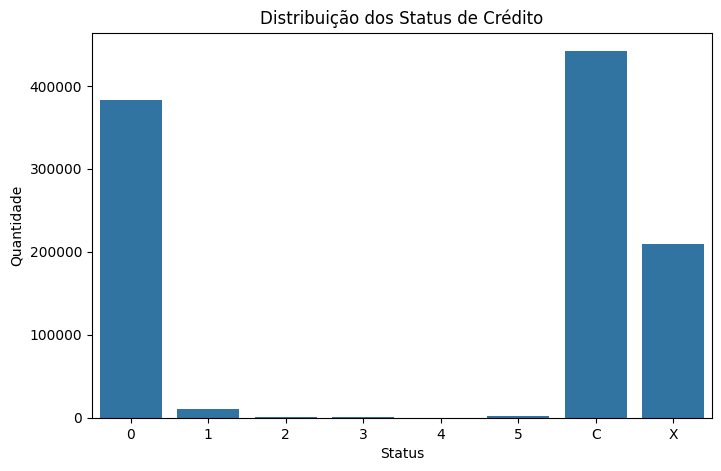

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=credit,
    x="STATUS",
    order=sorted(credit["STATUS"].unique())
)

plt.title("Distribuição dos Status de Crédito")
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.show()

**Construção de variável alvo**

Status cosiderado como inadimplência

In [51]:
bad_status=["1", "2", "3", "4", "5"]

In [52]:
credit["BAD_STATUS"] = credit["STATUS"].isin(bad_status).astype(int)

In [53]:
credit.head()

,ID,MONTHS_BALANCE,STATUS,BAD_STATUS
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


**HIstórico mensal em classificação do cliente.**

Se o cliente teve pelo menos um status ruim, ele será classificado como mau pagador.

In [54]:
target = (
    credit
    .groupby("ID")["BAD_STATUS"]
    .max()
    .reset_index()
)

In [55]:
target = target.rename(columns={
    "BAD_STATUS": "TARGET"
})

TARGET = 0 → bom pagador

TARGET = 1 → mau pagador

In [56]:
target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


distribuição da variável-alvo

In [57]:
target["TARGET"].value_counts()

,count
TARGET,
0,40635
1,5350


In [58]:
target["TARGET"].value_counts(normalize=True) * 100

,proportion
TARGET,
0,88.365771
1,11.634229


Isso revela um problema importante:

Desbalanceamento de classes

Temos muito mais bons pagadores do que maus pagadores.

Por isso accuracy sozinha não é uma boa métrica.

Por isso vamos usar:

Precision, Recall, F1, ROC-AUC, PR-AUC,  e Balanced Accuracy

Juntar as duas bases.
Esse será nosso dataset final de modelagem.

In [59]:
df = application.merge(
    target,
    on="ID",
    how="inner"
)

In [60]:
print(df.shape)
df.head()

(36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


**Verificação do target**

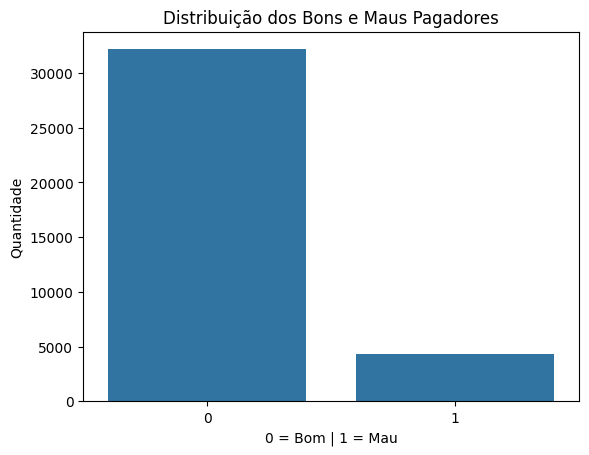

In [61]:
sns.countplot(data=df, x="TARGET")

plt.title("Distribuição dos Bons e Maus Pagadores")
plt.xlabel("0 = Bom | 1 = Mau")
plt.ylabel("Quantidade")
plt.show()

**Análise exploratória — idade**

In [62]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

Na base a idade está números negativos. Vamos transformar em anos.

In [63]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

In [64]:
df["AGE_YEARS"].describe()

,AGE_YEARS
count,36457.000000
mean,43.737641
std,11.500479
min,20.503765
25%,34.119097
50%,42.609172
75%,53.218344
max,68.862423


Agora é possível comparar bons e maus pagadores por idade

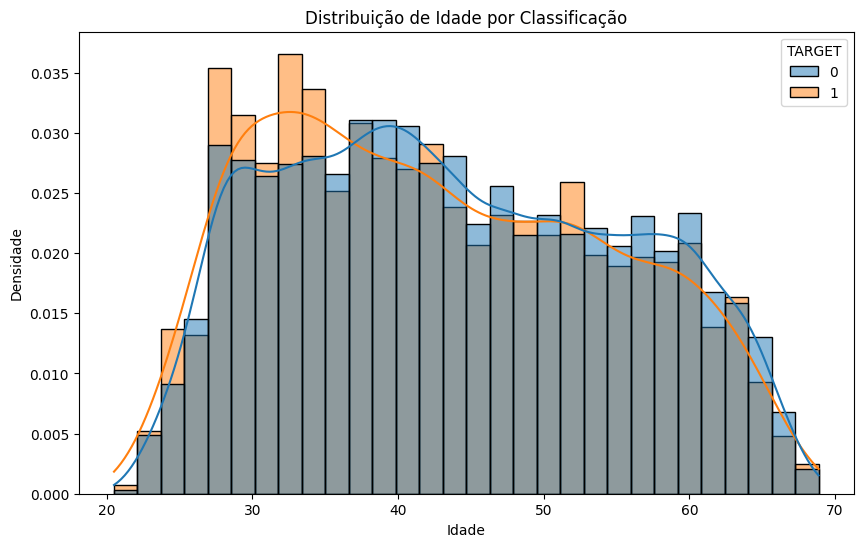

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="AGE_YEARS",
    hue="TARGET",
    bins=30,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição de Idade por Classificação")
plt.xlabel("Idade")
plt.ylabel("Densidade")
plt.show()

**Análise da renda**

In [66]:
df["AMT_INCOME_TOTAL"].describe()

,AMT_INCOME_TOTAL
count,3.645700e+04
mean,1.866857e+05
std,1.017892e+05
min,2.700000e+04
25%,1.215000e+05
50%,1.575000e+05
75%,2.250000e+05
max,1.575000e+06


Podemos observar que renda costuma ter distribuição bastante assimétrica.

In [67]:
df["INCOME_LOG"] = np.log1p(df["AMT_INCOME_TOTAL"])

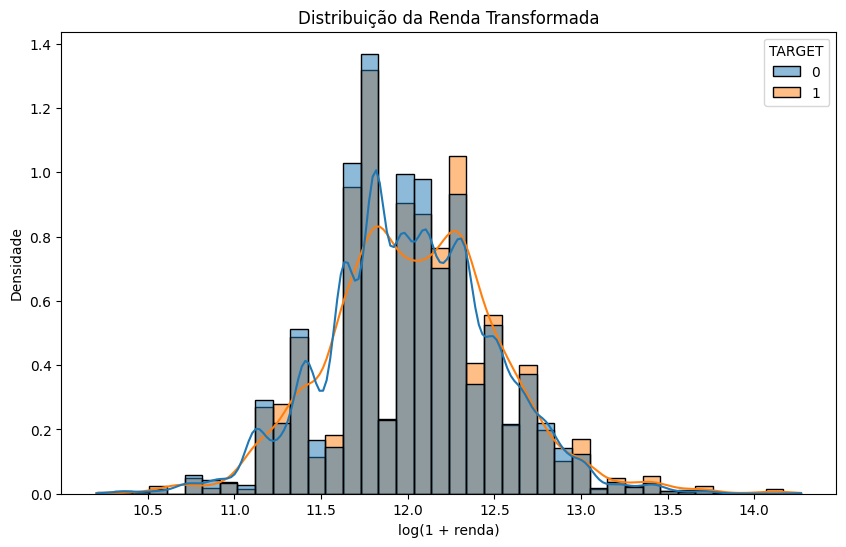

In [68]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="INCOME_LOG",
    hue="TARGET",
    bins=40,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuição da Renda Transformada")
plt.xlabel("log(1 + renda)")
plt.ylabel("Densidade")
plt.show()

**Renda por número de pessoas da família**

In [69]:
df["INCOME_PER_FAMILY"] = (
    df["AMT_INCOME_TOTAL"] /
    df["CNT_FAM_MEMBERS"].replace(0, np.nan)
)

**Tempo de emprego**

Essa variável tem dois problemas:

1- está em dias negativos.

2- Existe um valor que se repete "365243", que representa uma codificação de ausência de informação.

In [70]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan
)

In [71]:
df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365.25

**Testando algumas relações categóricas**

tipo de renda

como TARGET vale 0 ou 1, a média representa a proporção de maus pagadores.

In [72]:
income_type_target = (
    df.groupby("NAME_INCOME_TYPE")["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

income_type_target

,mean,count
NAME_INCOME_TYPE,,
State servant,0.128978,2985
Commercial associate,0.127208,8490
Working,0.115894,18819
Pensioner,0.104681,6152
Student,0.090909,11


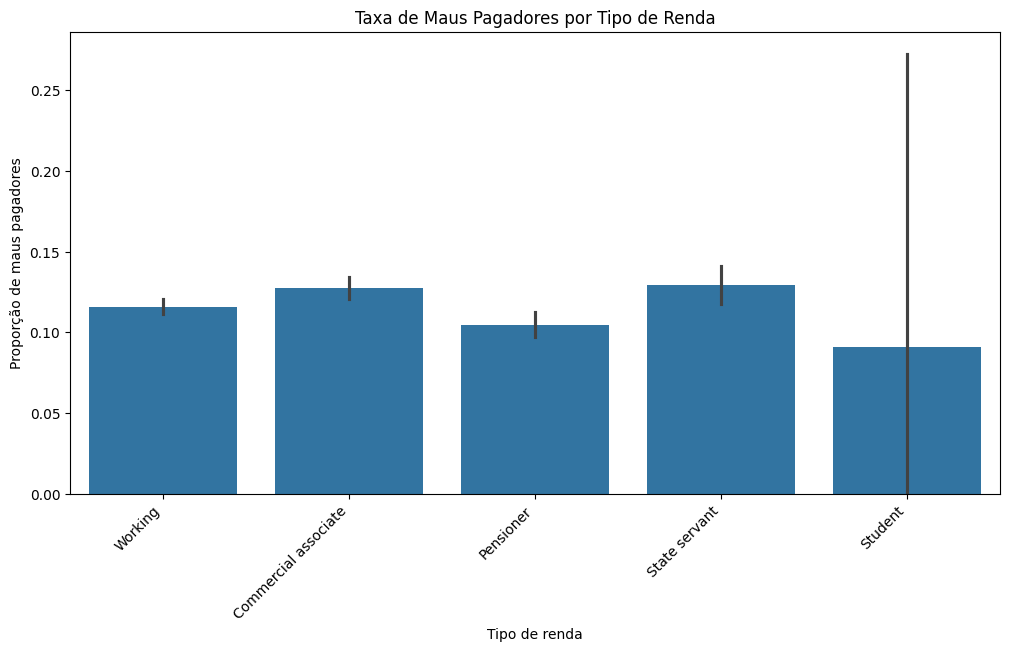

In [73]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="NAME_INCOME_TYPE",
    y="TARGET"
)

plt.xticks(rotation=45, ha="right")
plt.title("Taxa de Maus Pagadores por Tipo de Renda")
plt.xlabel("Tipo de renda")
plt.ylabel("Proporção de maus pagadores")
plt.show()

*Obs.: isso mostra associação nos dados, não significa que o tipo de renda seja a causa da inadimplência.*

**Escolaridade**

In [74]:
education_target = (
    df.groupby("NAME_EDUCATION_TYPE")["TARGET"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

education_target

,mean,count
NAME_EDUCATION_TYPE,,
Academic degree,0.218750,32
Incomplete higher,0.146809,1410
Secondary / secondary special,0.116640,24777
Higher education,0.116383,9864
Lower secondary,0.104278,374


### **Machine Learning**

Não queremos usar:

ID

TARGET

DAYS_BIRTH

DAYS_EMPLOYED

AMT_INCOME_TOTAL

porque:

ID é identificador;

TARGET é justamente o que queremos prever;

criamos versões mais interpretáveis de idade e emprego;

criamos INCOME_LOG para representar renda de forma mais adequada.

In [75]:
X = df.drop(
    columns=[
        "ID",
        "TARGET",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "AMT_INCOME_TOTAL"
    ]
)

y = df["TARGET"]

In [76]:
print(X.shape)
print(y.shape)

(36457, 18)
(36457,)


**Separando variáveis numéricas e categóricas**

In [77]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variáveis numéricas:")
print(numeric_features)

print("\nVariáveis categóricas:")
print(categorical_features)

Variáveis numéricas:
['CNT_CHILDREN', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'INCOME_LOG', 'INCOME_PER_FAMILY', 'EMPLOYED_YEARS']

Variáveis categóricas:
['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


**Separar treino e teste**

Decisão do grupo:

80% treinamento

20% teste

*Obs.: Isso irá preservar a mesma proporção de bons e maus pagadores nos dois conjuntos.*

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [79]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True))

Treino: (29165, 18)
Teste: (7292, 18)

Distribuição no treino:
TARGET
0    0.88229
1    0.11771
Name: proportion, dtype: float64

Distribuição no teste:
TARGET
0    0.882337
1    0.117663
Name: proportion, dtype: float64


**Pré-processamento**

Temos dois tipos de variável.

**Numéricas**

Vamos:

preencher valores ausentes pela mediana;

padronizar.

**Categóricas**

Vamos:

preencher valores ausentes pela categoria mais frequente;

transformar categorias em variáveis numéricas com One-Hot Encoding.

In [80]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [81]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

**Primeiro modelo: Regressão Logística**

In [82]:
class_weight="balanced"

In [83]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor criado com sucesso!")

Preprocessor criado com sucesso!


In [85]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=0.5
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=2000))])

**Random Forest**

*Esse foi o modelo que apresentou o melhor desempenho geral no nosso experimento.*

In [86]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=5,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

*Treino*

In [87]:
rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=5, n_estimators=400,
                                        n_jobs=-1, random_state=42))])

**Extra Trees**

*Nosso terceiro modelo*

In [88]:
extra_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=400,
                min_samples_leaf=3,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

*Treino*

In [89]:
extra_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN', 'FLAG_MOBIL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS', 'INCOME_LOG',
                                                   'INCOME_PER_FAMILY',
                                                   'EMPLOYED_YEARS']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE'])])),
                ('classifier',
                 ExtraTreesClassifier(class_weight='balanced',
                                      min_samples_leaf=3, n_estimators=400,
                                      n_jobs=-1, random_state=42))])

**Função para Avaliação**

In [90]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        )
    }

    return metrics

**Avaliando os três modelos**

In [91]:
results = []

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "Extra Trees": extra_model
}

for name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy"
    ]
]

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Balanced Accuracy
0,Logistic Regression,0.577894,0.137728,0.491841,0.215196,0.548888,0.142396,0.540605
1,Random Forest,0.841333,0.373626,0.515152,0.433121,0.780194,0.375759,0.699991
2,Extra Trees,0.794707,0.309708,0.606061,0.409933,0.770355,0.368386,0.712962


**Random Forest**

ROC-AUC = 0,780  indica uma capacidade razoável de separar bons e maus pagadores.

Recall ≈ 0,515 significa que encontramos aproximadamente 52% dos maus pagadores usando o limiar padrão.

Precision ≈ 0,373 significa que, entre os clientes classificados como maus, aproximadamente 37% realmente pertencem à classe ruim.

**Por que Extra Trees não foi escolhido**

Recall ≈ 0,608 Foi melhor que Random Forest, ou seja, ele consegue encontrar mais maus pagadores.

Porém apresentou:

Precision ≈ 0,309

F1 ≈ 0,409

ROC-AUC ≈ 0,770

PR-AUC ≈ 0,367

E o Random Forest apresentou desempenho geral superior em ROC-AUC, PR-AUC e F1.

Então nossa conclusão é o Random Forest foi escolhido como melhor modelo geral, enquanto Extra Trees apresentou vantagem específica na identificação de maus pagadores.

**Matriz de confusão**

*para analisar o Random Forest*

In [92]:
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

cm

array([[5693,  741],
       [ 416,  442]])

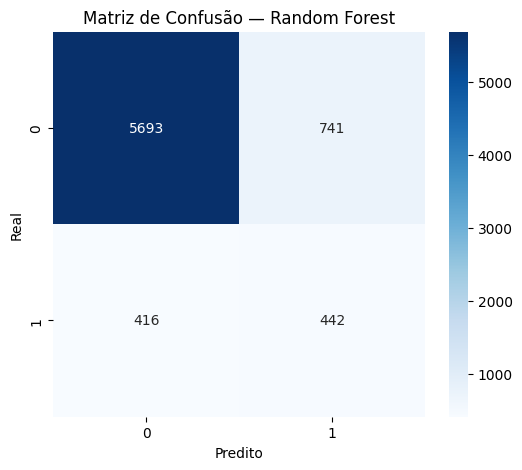

In [93]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão — Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**Curva ROC**

*A Curva ROC é uma ferramenta gráfica utilizada para avaliar o desempenho de um classificador binário, como os seus modelos. Ela plota a Taxa de Verdadeiros Positivos (TPR) contra a Taxa de Falsos Positivos (FPR) em vários limiares de classificação. Essencialmente, mostra a capacidade do modelo de distinguir entre as classes positivas (maus pagadores) e negativas (bons pagadores).*

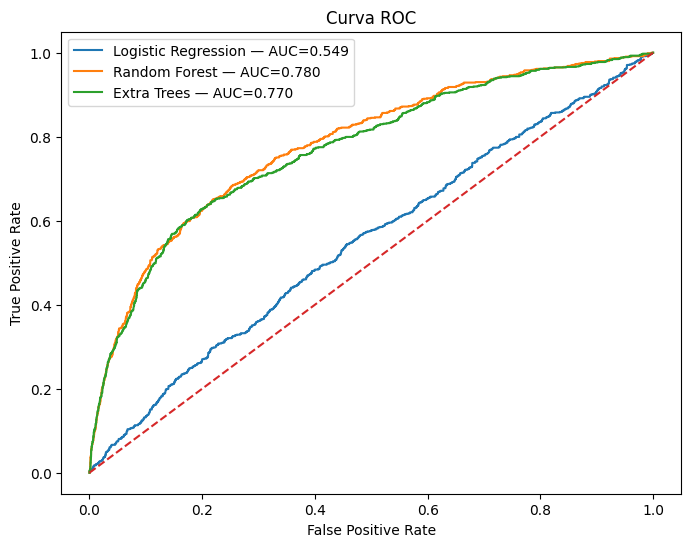

In [94]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} — AUC={auc:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

**Curva Precision-Recall**

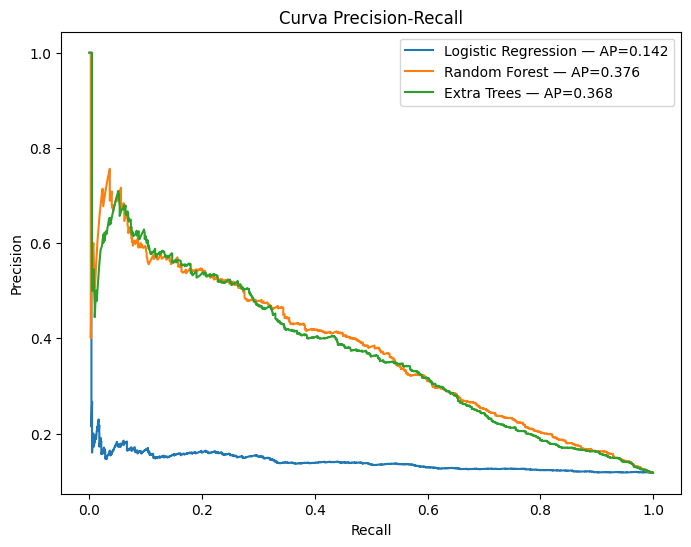

In [95]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} — AP={ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.show()

**Variáveis mais influenciam a previsão**

In [96]:
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [97]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
14,AGE_YEARS,0.074596
2,FLAG_OWN_REALTY,0.071705
12,OCCUPATION_TYPE,0.059760
4,NAME_INCOME_TYPE,0.052236
17,EMPLOYED_YEARS,0.046698
5,NAME_EDUCATION_TYPE,0.040363
15,INCOME_LOG,0.035134
0,CODE_GENDER,0.034206
16,INCOME_PER_FAMILY,0.033686
6,NAME_FAMILY_STATUS,0.033522


**Gráfico das principais variáveis**

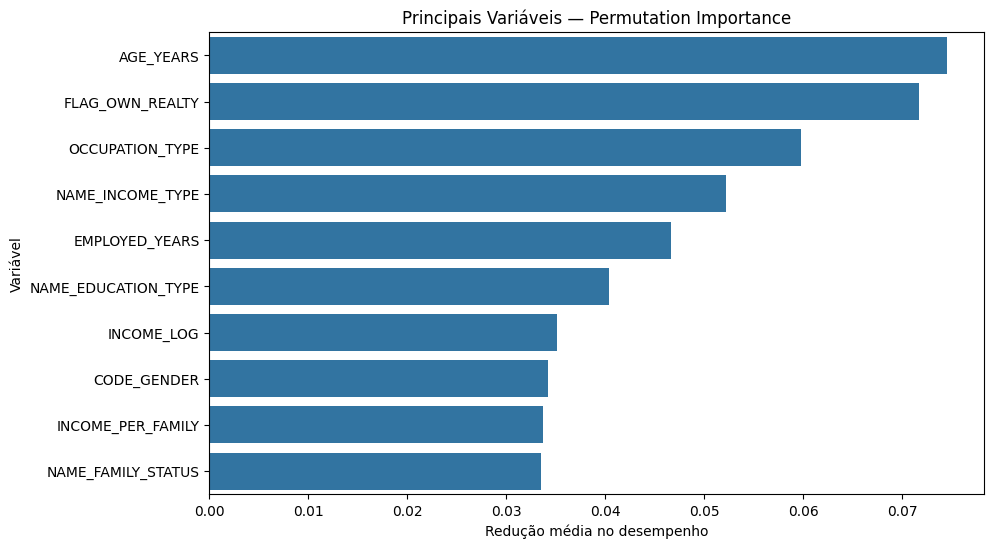

In [98]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Principais Variáveis — Permutation Importance"
)

plt.xlabel(
    "Redução média no desempenho"
)

plt.ylabel("Variável")

plt.show()

*A idade apresentou elevada importância preditiva no modelo*

**Github**

In [99]:
results_df.to_csv(
    "metricas_modelos.csv",
    index=False
)

importance_df.to_csv(
    "importancia_variaveis.csv",
    index=False
)

In [100]:
predictions = pd.DataFrame({
    "y_real": y_test.values,
    "y_pred": y_pred_rf,
    "probabilidade_mau_pagador": rf_model.predict_proba(X_test)[:, 1]
})

predictions.to_csv(
    "predicoes_random_forest.csv",
    index=False
)

In [101]:
files.download("metricas_modelos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [102]:
files.download("importancia_variaveis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
files.download("predicoes_random_forest.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1. A base de aplicação fornece as características do cliente.

2. A base de crédito fornece o comportamento histórico.

3. Criamos uma variável-alvo a partir do histórico.

4. Consideramos como mau pagador quem apresentou pelo menos um STATUS de 1 a 5.

5. Cruzamos o comportamento histórico com os dados cadastrais.

6. Fizemos limpeza e engenharia de atributos.

7. Dividimos os dados em treino e teste.

8. Criamos um pipeline de pré-processamento.

9. Treinamos três algoritmos diferentes.

10. Comparamos os modelos utilizando métricas adequadas ao desbalanceamento.

11. Random Forest apresentou o melhor desempenho geral.

12. Extra Trees teve maior capacidade de recuperar maus pagadores, mas com mais falsos positivos.

13. Finalmente, usamos permutation importance para entender quais variáveis tinham maior importância preditiva.